## Team members

-  Gaaze Verena 22B030332
- Sabibolda Akzhan 22B030582
- Sazanova Aruzhan 22B030429

## Imports

In [8]:
import argparse
import os
import numpy as np
from typing import Tuple
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Topic 1: Transportation and delivery scheduling (MLP)

## Dataset Preporation

### Сore geometry and routing functions

In [9]:
def dist(a,b):
  #Eucledean distance between two 2D points.
  return float(np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2))

In [10]:
def nn_route_length(depot, pts):
  #Nearest-neighbor routing length
  #depot -> all points -> depot
  if len(pts) == 0:
    return 0.0

  unvisited = pts.copy()
  cur = depot
  total_len = 0.0

  while unvisited:
    idx = min(
        range(len(unvisited)),
        key=lambda i: dist(cur, unvisited[i])
    )
    nxt = unvisited.pop(idx)
    total_len += dist(cur, nxt)
    cur = nxt

  total_len += dist(cur, depot)
  return total_len

In [11]:
#Test NN-routing on a known example
depot = (0, 0)
pts = [(1,0), (0,1), (1,1)]

nn_route_length(depot, pts)

4.0

### Brute-force optimal assignment

In [12]:
def best_assignment_two_courriers(depot, points_xy):
  """ Enumerate all 2^n assigments and finds the one minimizing
  the makespan under NN routing.
  Returns: best_makespan, best_mask, route_len_A, route_len_B"""

  N = len(points_xy)
  best = None

  for mask in range(1 << N):
    A = [points_xy[i] for i in range(N) if ((mask >> i) & 1) == 0]
    B = [points_xy[i] for i in range(N) if ((mask >> i) & 1) == 1]

    LA = nn_route_length(depot, A)
    LB = nn_route_length(depot, B)
    makespan = max(LA, LB)

    if best is None or makespan < best[0]:
      best = (makespan, mask, LA, LB)

  return best


In [13]:
pts = [(1,0), (0,1), (1,1), (2,0)]
best_assignment_two_courriers((0,0), pts)

(4.0, 6, 4.0, 3.414213562373095)

### Dataset Generation 

In [14]:
#Dataset generation
def make_dataset(num_samples, N, seed, low=0.0, high=2.0):
  """ Generates (X, y) dataset.
  X shape: (num_samples, 2N)
  y shape: (num_samples, N)"""
  rng = np.random.default_rng(seed)
  depot = (0.0, 0.0)

  X = np.zeros((num_samples, 2 * N), dtype = np.float32)
  y = np.zeros((num_samples, N), dtype=np.int64)

  for s in range(num_samples):
    pts = rng.uniform(low=low, high=high, size=(N,2)).astype(np.float32)

    best_makespan, best_mask, _, _ = best_assignment_two_courriers(
        depot, pts.tolist()
    )

    X[s] = pts.reshape(-1)
    for i in range(N):
      y[s, i] = (best_mask >> i) & 1

  return X, y

In [15]:
#generate a tiny dataset for sanity check
""" This cell verifies that the dataset generator
produces correctly shaped inputs and optimal binary
courier assignments, and that the assignments are geometrically
consistent with makespan minimization."""
X, y = make_dataset(num_samples=5, N=4, seed=42)
X,y

(array([[1.5479121 , 0.8777569 , 1.7171959 , 1.394736  , 0.1883547 ,
         1.9512447 , 1.5222794 , 1.5721287 ],
        [0.25622725, 0.90077186, 0.74159604, 1.8535299 , 1.2877302 ,
         1.6455232 , 0.8868284 , 0.45447743],
        [1.1091696 , 0.12763451, 1.6552624 , 1.2633288 , 1.5161755 ,
         0.7090519 , 1.941396  , 1.7862422 ],
        [1.556767  , 0.38927743, 0.933442  , 0.08760753, 0.308579  ,
         1.3660979 , 1.4895244 , 1.9350195 ],
        [0.6516507 , 0.7409194 , 0.93911165, 0.37894273, 0.25984302,
         0.9514099 , 0.4538187 , 1.339628  ]], dtype=float32),
 array([[0, 0, 1, 0],
        [1, 1, 0, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 0],
        [1, 1, 0, 0]]))

### Splitting the dataset

In [16]:
#Train/Valid/ Test split

def split_dataset(X, y, seed, ratios=(0.8, 0.1, 0.1)):
  #Splits dataset into train/val/test

  assert abs(sum(ratios) - 1.0) < 1e-6

  rng = np.random.default_rng(seed)
  idx = rng.permutation(len(X))

  n_train = int(ratios[0] * len(X))
  n_val = int(ratios[1] * len(X))

  train_idx = idx[:n_train]
  val_idx = idx[n_train:n_train + n_val]
  test_idx = idx[n_train + n_val:]

  return (
      X[train_idx], y[train_idx],
      X[val_idx], y[val_idx],
      X[test_idx], y[test_idx]
  )

In [17]:
#split check
X_train, y_train, X_val, y_val, X_test, y_test = split_dataset(X,y, seed=42)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(4, 8) (4, 4)
(0, 8) (0, 4)
(1, 8) (1, 4)


### Dataset generation Final 

In [18]:
#Save dataset to .npz

def save_npz(path, X_train, y_train, X_val, y_val, X_test, y_test, meta):
  #Saves dataset splits and metadata to .npz

  np.savez (
      path,
      X_train=X_train,
      y_train=y_train,
      X_val=X_val,
      y_val=y_val,
      X_test=X_test,
      y_test=y_test,
      meta=meta
  )

In [19]:
#Full dataset generation (final)
X, y = make_dataset(num_samples=5000, N=8, seed=0)

X_train, y_train, X_val, y_val, X_test, y_test = split_dataset(X, y, seed=0)

save_npz("./dataset",
         X_train, y_train,
         X_val, y_val,
         X_test, y_test,
         meta= {
             "N": 8,
             "seed": 0,
             "num_samples": 5000,
             "coord_low": 0.0,
             "coord_high": 2.0
         })

## Model and Training

### Loading prepared Dataset

In [20]:
data = np.load("./dataset.npz", allow_pickle=True)

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

meta = data["meta"].item()
N = meta["N"]

X_train.shape, y_train.shape

# converting data to pytorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# creating data loaders
batch_size = 64

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=batch_size,
    shuffle=False
)

### MLP Model

In [21]:
class CourierAssignmentMLP(nn.Module):
    # input:  2N floats - coordinates
    # output: N sigmoid probabilities - courier B assignment
    def __init__(self, N):
        super().__init__()
        input_dim = 2 * N
        output_dim = N
        hidden_size = 256 # will improve the model performance

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2), 
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2), 
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2), 
            nn.Linear(hidden_size, output_dim)
        )

    def forward(self, x):
        return self.net(x)
    
# instantiating model
model = CourierAssignmentMLP(N).to(device)

# parameter count
num_params = sum(p.numel() for p in model.parameters())
num_params

# loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4)

### Training loop with validation and early stopping

In [22]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    max_epochs=100,
    patience=10
):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None

    for epoch in range(max_epochs):

        # training
        model.train()
        total_train_loss = 0.0
        correct_bits = 0
        total_bits = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item() * xb.size(0)

            # bit accuracy
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct_bits += (preds == yb).sum().item()
            total_bits += yb.numel()

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_acc = correct_bits / total_bits
        
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)

        # validation
        model.eval()
        total_val_loss = 0.0
        correct_bits = 0
        total_bits = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                logits = model(xb)
                loss = criterion(logits, yb)
                total_val_loss += loss.item() * xb.size(0)
                preds = (torch.sigmoid(logits) > 0.5).float()
                correct_bits += (preds == yb).sum().item()
                total_bits += yb.numel()

        avg_val_loss = (
            total_val_loss / len(val_loader.dataset)
            if len(val_loader.dataset) > 0 else avg_train_loss
        )

        val_acc = correct_bits / total_bits if total_bits > 0 else train_acc

        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Train Acc: {train_acc:.3f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_acc:.3f}"
        )

        # early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("early stopping triggered")
                break

    model.load_state_dict(best_state)
    return train_losses, val_losses, train_accs, val_accs

### Training our Model

In [23]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    max_epochs=100,
    patience=10
)

Epoch 001 | Train Loss: 0.6207 | Train Acc: 0.571 | Val Loss: 0.6059 | Val Acc: 0.589
Epoch 002 | Train Loss: 0.6058 | Train Acc: 0.588 | Val Loss: 0.5994 | Val Acc: 0.607
Epoch 003 | Train Loss: 0.5989 | Train Acc: 0.613 | Val Loss: 0.5957 | Val Acc: 0.628
Epoch 004 | Train Loss: 0.5932 | Train Acc: 0.633 | Val Loss: 0.5899 | Val Acc: 0.644
Epoch 005 | Train Loss: 0.5856 | Train Acc: 0.648 | Val Loss: 0.5826 | Val Acc: 0.661
Epoch 006 | Train Loss: 0.5770 | Train Acc: 0.664 | Val Loss: 0.5728 | Val Acc: 0.671
Epoch 007 | Train Loss: 0.5658 | Train Acc: 0.677 | Val Loss: 0.5596 | Val Acc: 0.691
Epoch 008 | Train Loss: 0.5524 | Train Acc: 0.693 | Val Loss: 0.5493 | Val Acc: 0.691
Epoch 009 | Train Loss: 0.5414 | Train Acc: 0.703 | Val Loss: 0.5387 | Val Acc: 0.712
Epoch 010 | Train Loss: 0.5314 | Train Acc: 0.712 | Val Loss: 0.5344 | Val Acc: 0.708
Epoch 011 | Train Loss: 0.5246 | Train Acc: 0.716 | Val Loss: 0.5255 | Val Acc: 0.713
Epoch 012 | Train Loss: 0.5204 | Train Acc: 0.720 | Va

### Training and Validation loss over epochs plot

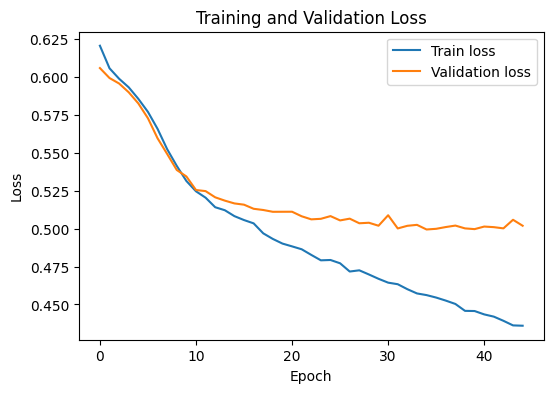

In [24]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

### Training and Validation accuracy over epochs plot

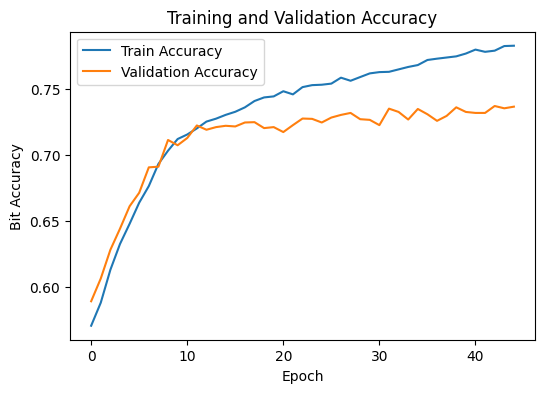

In [25]:
plt.figure(figsize=(6,4))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Bit Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

### Saving the model

In [26]:
model_path = "./courier_assignment_mlp.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to ./courier_assignment_mlp.pth


### Function to load our model

In [27]:
def load_trained_model(model_class, N, model_path, device="cpu"):
    # instantiate the model
    model = model_class(N).to(device)

    # load saved weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    
    # set to evaluation mode
    model.eval()
    
    print(f"Model loaded from {model_path} and ready for evaluation.")
    return model

# Example usage:
# loaded_model = load_trained_model(CourierAssignmentMLP, N, "./courier_assignment_mlp.pth", device=device)

## Evaluation, Testing and Visualization

### Loading Test Dataset and Trained Model

In [28]:
import numpy as np
import torch
import matplotlib.pyplot as plt

data = np.load("./dataset.npz", allow_pickle=True)
X_test = data["X_test"].astype(np.float32)
y_test = data["y_test"].astype(np.int64)

meta = data["meta"].item()
N = int(meta["N"])

device = "cuda" if torch.cuda.is_available() else "cpu"
model = load_trained_model(CourierAssignmentMLP, N, "./courier_assignment_mlp.pth", device=device)

print("Test samples:", X_test.shape[0])


Model loaded from ./courier_assignment_mlp.pth and ready for evaluation.
Test samples: 500


### Assignment Accuracy Metrics

In [29]:
def predict_assignments(model, X, device="cpu", threshold=0.5):
    model.eval()
    preds = []
    with torch.no_grad():
        xb = torch.tensor(X, device=device)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= threshold).astype(np.int64)
    return preds

y_pred = predict_assignments(model, X_test, device=device)

bit_accuracy = (y_pred == y_test).mean()
exact_accuracy = (y_pred == y_test).all(axis=1).mean()

print(f"Bit accuracy: {bit_accuracy:.4f}")
print(f"Exact-match accuracy: {exact_accuracy:.4f}")


Bit accuracy: 0.7280
Exact-match accuracy: 0.1680


### Makespan Evaluation (Solution Quality)

In [30]:
depot = (0.0, 0.0)

def makespan(x_flat, assignment):
    pts = x_flat.reshape(N, 2).tolist()
    A = [pts[i] for i in range(N) if assignment[i] == 0]
    B = [pts[i] for i in range(N) if assignment[i] == 1]
    return max(nn_route_length(depot, A), nn_route_length(depot, B))

ms_opt = np.array([makespan(X_test[i], y_test[i]) for i in range(len(X_test))])
ms_pred = np.array([makespan(X_test[i], y_pred[i]) for i in range(len(X_test))])

gap = ms_pred - ms_opt
ratio = ms_pred / (ms_opt + 1e-9)

print("Mean optimal makespan:", ms_opt.mean())
print("Mean predicted makespan:", ms_pred.mean())
print("Mean gap:", gap.mean())
print("Median ratio:", np.median(ratio))
print("95th percentile ratio:", np.percentile(ratio, 95))


Mean optimal makespan: 4.935131758917647
Mean predicted makespan: 5.347669531820539
Mean gap: 0.412537772902891
Median ratio: 1.0558477953416205
95th percentile ratio: 1.279066439751864


### Distribution Analysis

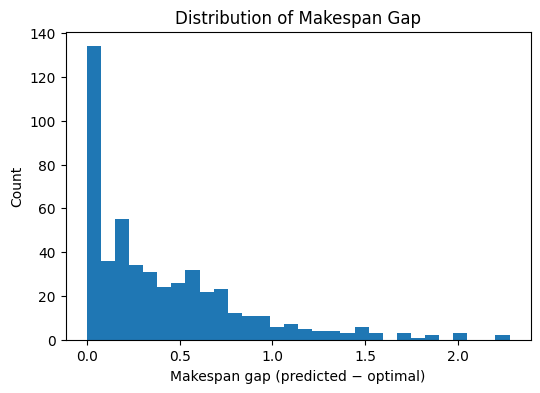

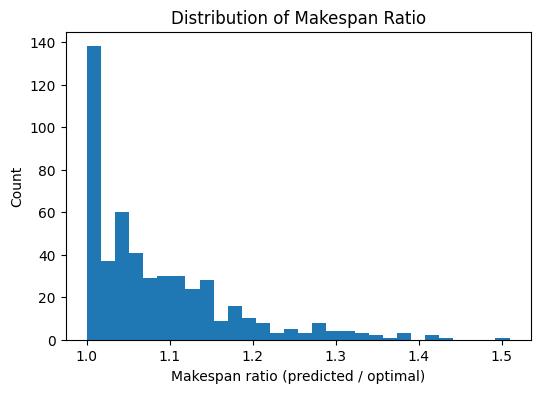

In [31]:
plt.figure(figsize=(6,4))
plt.hist(gap, bins=30)
plt.xlabel("Makespan gap (predicted − optimal)")
plt.ylabel("Count")
plt.title("Distribution of Makespan Gap")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(ratio, bins=30)
plt.xlabel("Makespan ratio (predicted / optimal)")
plt.ylabel("Count")
plt.title("Distribution of Makespan Ratio")
plt.show()


### Route Visualization

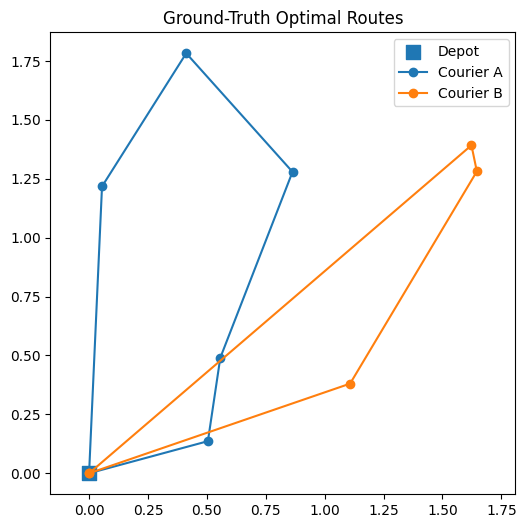

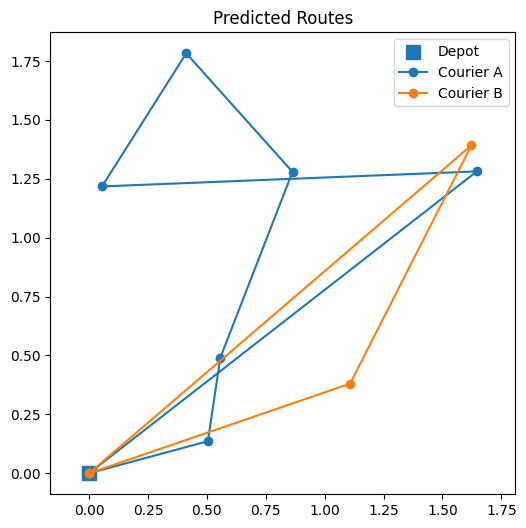

In [32]:
def nn_order(depot, pts):
    if not pts:
        return []
    unvisited = list(range(len(pts)))
    cur = depot
    order = []
    while unvisited:
        j = min(unvisited, key=lambda k: dist(cur, pts[k]))
        order.append(j)
        cur = pts[j]
        unvisited.remove(j)
    return order

def plot_routes(x_flat, assignment, title):
    pts = x_flat.reshape(N,2).tolist()
    A = [pts[i] for i in range(N) if assignment[i]==0]
    B = [pts[i] for i in range(N) if assignment[i]==1]

    plt.figure(figsize=(6,6))
    plt.scatter([0],[0], marker="s", s=100, label="Depot")

    for pts_set, label in [(A,"Courier A"), (B,"Courier B")]:
        order = nn_order(depot, pts_set)
        path = [depot] + [pts_set[i] for i in order] + [depot]
        plt.plot([p[0] for p in path], [p[1] for p in path], marker="o", label=label)

    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.show()

idx = np.argmax(gap)

plot_routes(X_test[idx], y_test[idx], "Ground-Truth Optimal Routes")
plot_routes(X_test[idx], y_pred[idx], "Predicted Routes")


### Summary

The evaluation results show that the trained neural network provides a good
approximation of the optimal courier assignment problem.

At the assignment level, the model achieves a **bit accuracy of 0.728**, which means
that most individual delivery points are assigned to the correct courier. The
**exact-match accuracy of 0.168** is much lower, which is expected for this task,
because even one incorrect assignment makes the whole assignment vector incorrect.
Therefore, exact-match accuracy is a very strict metric and does not fully reflect the
quality of the solution.

From the optimization point of view, the model performs well. The **mean optimal
makespan** on the test set is **4.94**, while the **mean predicted makespan** is **5.35**.
This results in an average gap of **0.41**. In relative terms, the **median makespan
ratio is 1.056**, meaning that in half of the test cases the predicted solution is
within about **6%** of the optimal one.

The **95th percentile ratio of 1.279** shows that even in difficult cases the predicted
makespan usually does not exceed the optimal value by more than **28%**. The histogram
of makespan gaps confirms that most predictions are close to the optimal solution, and
large errors occur rarely.

The route visualizations support these results. The predicted routes are very similar
to the optimal routes, and the differences mainly come from deliveries that have a
small effect on the total route length.

Overall, the results indicate that the neural network learns the main structure of the
problem and produces near-optimal solutions with much lower computational cost than
brute-force search. This makes the approach suitable for practical scenarios where fast
decisions are required.
